Optional HW-4:

Попробуйте написать классификатор на основе CNN2d, MaxPool2d, BatchNorm, Dropout, FC; в 6 слоев; которые на выходе будет классифицировать следующие картинки как фейк или реал: https://www.kaggle.com/datasets/cashbowman/ai-generated-images-vs-real-images

f1-score macro - побейте 60%

P.S. там есть решения с кодом, но советую пробовать самостоятельно!

P.S.S посмотрите библиотеку https://pypi.org/project/opencv-python/

In [1]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.2 MB/s eta 0:00:0000:0100:010m
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 MB 636.0 kB/s eta 0:00:0000:0100:02
Note: you may need to restart the kernel to use updated packages.


In [17]:
import cv2 as cv
import torch
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import numpy as np

In [ ]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True)

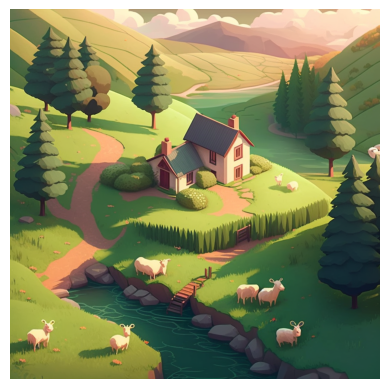

In [37]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/Users/tolkyn.zhagipar/Downloads/archive/AiArtData/AiArtData/_a_peaceful_countryside_Beaches_with_a__2edf54e5-d4e4-4507-abde-4f81b9754b54.png")  # Reads as BGR by default
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

plt.imshow(image_rgb)
plt.axis("off")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_epochs = 10
batch_size = 64
learning_rate = 0.001

# Data preprocessing and augmentation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize with mean and std
])

# Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # Conv1
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Pool1
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # Conv2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Pool2
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),# Conv3
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                  # Pool3
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),  # Fully connected layer
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)           # Output layer for 10 classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model, loss, and optimizer
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
print("Training the model...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluation on the test dataset
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

# Visualize predictions
classes = train_dataset.classes  # Class names
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predictions = torch.max(outputs, 1)

# Display some test images with their predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].cpu().permute(1, 2, 0) / 2 + 0.5)  # Unnormalize
    plt.title(f"Predicted: {classes[predictions[i]]}\nActual: {classes[labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
